In [1]:
from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics
import numpy as np

from matplotlib import pyplot as plt

import pandas as pd

import torch
from torch.nn import functional as F
from tqdm import tqdm

In [2]:
DEVICE = utils.get_device()

DEVICE

'cuda'

In [3]:
MODEL_NAME = "cifar100-resnet18-v1"
LAYER = "layer3"

DATASET_NAME = "cifar100"

In [4]:
dataset = datasets.construct(DATASET_NAME)

In [5]:
ds_train = dataset.create_subset(train_split=True)
dl_train = datasets.build_dataloader(ds_train, shuffle=False)
ds_val = dataset.create_subset(train_split=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

In [6]:
model = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(
    model=model,
    selected_classes=dataset.selected_classes
)
model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [7]:
logit_mod = attributors.WinningClassEvidence(num_classes=dataset.num_classes)

rng = np.random.default_rng(seed=1)

In [8]:
arr_act, arr_ctx = attributors.extract_activation_context(
    model=model,
    layer=LAYER,
    dataset=dataset,
    data_loader=dl_train,
    logit_modifier=logit_mod,
    rng=rng,
    number_of_selected_spatial_locations=64,
    device=DEVICE,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [01:01<00:00, 12.69it/s]


layer3: output-dims=torch.Size([256, 8, 8])


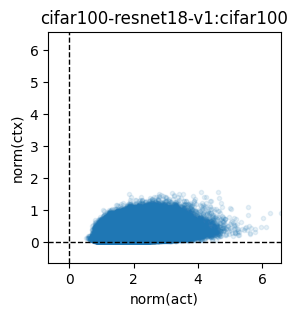

In [9]:
def viz_scale():

    arr_act_norm = np.linalg.norm(arr_act, axis=1)
    arr_ctx_norm = np.linalg.norm(arr_ctx, axis=1)
    plt.figure(figsize=(3, 3))
    
    plt.scatter(
        arr_act_norm,
        arr_ctx_norm,
        marker=".",
        alpha=0.1
    )
    vmax = np.max(arr_act_norm)
    vmin = -vmax * 0.1
    plt.title(f"{MODEL_NAME}:{DATASET_NAME}")
    plt.xlim([vmin, vmax])
    plt.ylim([vmin, vmax])
    plt.axvline(0, ls="--", lw=1, color="k")
    plt.axhline(0, ls="--", lw=1, color="k")
    plt.ylabel("norm(ctx)")
    plt.xlabel("norm(act)")
viz_scale()

In [10]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs


def estimate_basis(name):
    if name == "pca":
        return _solve_eigvecs(arr_act.T @ arr_act)
    elif name == "prca":
        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
            sort_func=np.abs
        )
        pass
    elif name == "pca-unitnorm":
        _arr_act = arr_act / np.linalg.norm(arr_act, axis=1, keepdims=True)
        return _solve_eigvecs(_arr_act.T @ _arr_act)
    elif name == "prca-unitnorm":
        _arr_act = arr_act / np.linalg.norm(arr_act, axis=1, keepdims=True)
        _arr_ctx = arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=True)
        return _solve_eigvecs(
            _arr_act.T @ _arr_ctx + _arr_ctx.T @ _arr_act ,
            sort_func=np.abs
        )
    else:
        raise

In [11]:
def ano():
    for basis_name in ["pca", "prca", "pca-unitnorm", "prca-unitnorm"]:
        estimate_basis(basis_name)
    print("sanity check: passed!")
ano()

sanity check: passed!


In [12]:
def construct_fh(UUk):

    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            UUk
        ) 

    return fh

@torch.no_grad()
def estimate_acc_at_k(basis_name, arr_ks):


    U = estimate_basis(basis_name)
    
    arr_rows = []

    for k in tqdm(arr_ks):
        Uk = U[:, :k]
        UUk = torch.from_numpy(Uk @ Uk.T).unsqueeze(2).unsqueeze(3).to(DEVICE)
        
        try:
            hook = getattr(model, LAYER).register_forward_hook(construct_fh(UUk))
            acc, xent = metrics.accuracy(
                model=model,
                dataloader=dl_val,
                num_classes=len(dataset.selected_classes),
                device=DEVICE
            )
            arr_rows.append(dict(
                basis_name=basis_name, 
                k=k,
                val_acc=acc,
                val_loss=xent
            ))
        finally:
            hook.remove()


    return pd.DataFrame(arr_rows)

estimate_acc_at_k("pca", np.arange(0, 10, 2).tolist() + [256])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:11<00:00,  1.98s/it]


,basis_name,k,val_acc,val_loss
0,pca,0,0.0100,7.182287
1,pca,2,0.0063,4.660522
2,pca,4,0.0196,4.583617
3,pca,6,0.0239,4.517908
4,pca,8,0.0481,4.368931
5,pca,256,0.7764,0.911800


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.69s/it]


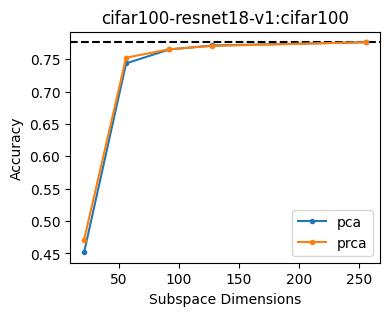

In [13]:
def viz():
    d = arr_act.shape[1]

    plt.figure(figsize=(4, 3))
    plt.title(f"{MODEL_NAME}:{DATASET_NAME}")
    
    arr_ks =  np.linspace(d//12, d//2, num=4).astype(int).tolist() + [d]
    for bix, basis_name in enumerate([
        "pca", 
        # "pca-unitnorm", 
        "prca", 
        # "prca-unitnorm"
    ]):
        df = estimate_acc_at_k(basis_name, arr_ks)

        if bix == 0:
            plt.axhline(df["val_acc"].values[-1], ls="--", color="k")

        if "unit" in basis_name:
            ls = ":"
            color= plt.gca().lines[-1].get_color()
        else:
            ls = "-"
            color = None
        plt.plot(
            df.k,
            df.val_acc,
            label=basis_name,
            color=color,
            ls=ls,
            marker="."
        )
    plt.xlabel("Subspace Dimensions")
    plt.ylabel("Accuracy")
    plt.legend()
viz()